# 📊 Linear Regression — All Assignments (Complete Solutions)
### Assignments 1–6 + Salary Prediction
---
**Datasets used:** California Housing (sklearn), Advertising (seaborn/csv), Diabetes (sklearn), Insurance (seaborn), synthetic salary data  
**Libraries:** numpy, pandas, matplotlib, seaborn, sklearn, scipy, statsmodels, joblib

In [1]:
import subprocess, sys
for pkg in ['statsmodels', 'joblib']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, joblib
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing, load_diabetes
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 11})
sns.set_palette('husl')

def print_metrics(y_true, y_pred, label='Model'):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f'\n{label}')
    print(f'  MAE  = {mae:.4f}')
    print(f'  MSE  = {mse:.4f}')
    print(f'  RMSE = {rmse:.4f}')
    print(f'  R2   = {r2:.4f}')
    return dict(label=label, MAE=mae, MSE=mse, RMSE=rmse, R2=r2)

print('All libraries imported successfully!')

All libraries imported successfully!


---
## 📌 Assignment 1 — Build Linear Regression From Scratch (No sklearn)
> Implement Linear Regression using **Gradient Descent** from scratch on California Housing Dataset.

In [2]:
housing = fetch_california_housing(as_frame=True)
df1 = housing.frame.copy()
print('Shape:', df1.shape)
df1.head()

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
print(df1.describe().T.round(2))
print(df1.isnull().sum())

               count     mean      std     min     25%      50%      75%  \
MedInc       20640.0     3.87     1.90    0.50    2.56     3.53     4.74   
HouseAge     20640.0    28.64    12.59    1.00   18.00    29.00    37.00   
AveRooms     20640.0     5.43     2.47    0.85    4.44     5.23     6.05   
AveBedrms    20640.0     1.10     0.47    0.33    1.01     1.05     1.10   
Population   20640.0  1425.48  1132.46    3.00  787.00  1166.00  1725.00   
AveOccup     20640.0     3.07    10.39    0.69    2.43     2.82     3.28   
Latitude     20640.0    35.63     2.14   32.54   33.93    34.26    37.71   
Longitude    20640.0  -119.57     2.00 -124.35 -121.80  -118.49  -118.01   
MedHouseVal  20640.0     2.07     1.15    0.15    1.20     1.80     2.65   

                  max  
MedInc          15.00  
HouseAge        52.00  
AveRooms       141.91  
AveBedrms       34.07  
Population   35682.00  
AveOccup      1243.33  
Latitude        41.95  
Longitude     -114.31  
MedHouseVal      5.00  

In [4]:
df1.fillna(df1.median(numeric_only=True), inplace=True)

Q1, Q3 = df1['MedHouseVal'].quantile([0.25, 0.75])
IQR = Q3 - Q1
df1 = df1[(df1['MedHouseVal'] >= Q1 - 1.5*IQR) & (df1['MedHouseVal'] <= Q3 + 1.5*IQR)]
print(f'Shape after outlier removal: {df1.shape}')

Shape after outlier removal: (19569, 9)


In [5]:
X1 = df1.drop('MedHouseVal', axis=1).values
y1 = df1['MedHouseVal'].values

X1_mean = X1.mean(axis=0)
X1_std  = X1.std(axis=0)
X1_norm = (X1 - X1_mean) / X1_std

split = int(0.8 * len(X1_norm))
X_tr, X_te = X1_norm[:split], X1_norm[split:]
y_tr, y_te = y1[:split], y1[split:]

X_tr_b = np.c_[np.ones(len(X_tr)), X_tr]
X_te_b = np.c_[np.ones(len(X_te)), X_te]
print('Training set:', X_tr_b.shape)

Training set: (15655, 9)


In [6]:
class LinearRegressionScratch:
    def __init__(self, lr=0.01, n_iter=1000):
        self.lr, self.n_iter = lr, n_iter
        self.weights = None
        self.cost_history = []

    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros(n)
        self.cost_history = []
        for _ in range(self.n_iter):
            y_hat  = X @ self.weights
            error  = y_hat - y
            grad   = (2/m) * X.T @ error
            self.weights -= self.lr * grad
            self.cost_history.append(np.mean((y - y_hat)**2))
        return self

    def predict(self, X):
        return X @ self.weights


class SGDLinearRegression:
    def __init__(self, lr=0.01, n_iter=50, batch_size=32):
        self.lr, self.n_iter, self.batch_size = lr, n_iter, batch_size
        self.weights = None
        self.cost_history = []

    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros(n)
        self.cost_history = []
        for _ in range(self.n_iter):
            idx = np.random.permutation(m)
            X_sh, y_sh = X[idx], y[idx]
            for i in range(0, m, self.batch_size):
                xb = X_sh[i:i+self.batch_size]
                yb = y_sh[i:i+self.batch_size]
                grad = (2/len(xb)) * xb.T @ (xb @ self.weights - yb)
                self.weights -= self.lr * grad
            self.cost_history.append(np.mean((X @ self.weights - y)**2))
        return self

    def predict(self, X):
        return X @ self.weights

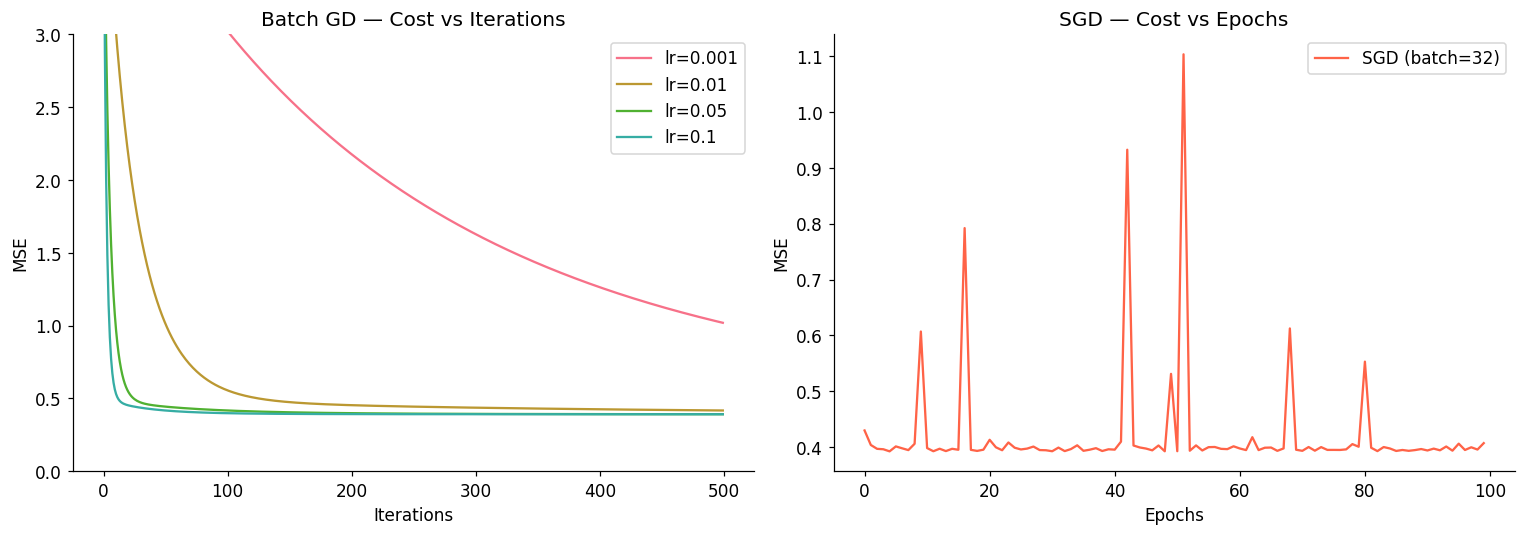

In [7]:
learning_rates = [0.001, 0.01, 0.05, 0.1]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_scratch = {}
for lr in learning_rates:
    m = LinearRegressionScratch(lr=lr, n_iter=500)
    m.fit(X_tr_b, y_tr)
    models_scratch[lr] = m
    axes[0].plot(m.cost_history, label=f'lr={lr}')

axes[0].set_title('Batch GD — Cost vs Iterations')
axes[0].set_xlabel('Iterations')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].set_ylim(0, 3)

sgd = SGDLinearRegression(lr=0.01, n_iter=100, batch_size=32)
sgd.fit(X_tr_b, y_tr)
axes[1].plot(sgd.cost_history, color='tomato', label='SGD (batch=32)')
axes[1].set_title('SGD — Cost vs Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('MSE')
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
y_pred_scratch = models_scratch[0.05].predict(X_te_b)
y_pred_sgd     = sgd.predict(X_te_b)

sk_lr = LinearRegression().fit(X_tr, y_tr)
y_pred_sk = sk_lr.predict(X_te)

r1a = print_metrics(y_te, y_pred_scratch, 'Scratch GD  (lr=0.05)')
r1b = print_metrics(y_te, y_pred_sgd,     'Scratch SGD (lr=0.01)')
r1c = print_metrics(y_te, y_pred_sk,      'sklearn LinearRegression')

print(pd.DataFrame([r1a, r1b, r1c]).set_index('label').round(4))


Scratch GD  (lr=0.05)
  MAE  = 0.4645
  MSE  = 0.3930
  RMSE = 0.6269
  R2   = 0.6162

Scratch SGD (lr=0.01)
  MAE  = 0.4765
  MSE  = 0.5093
  RMSE = 0.7137
  R2   = 0.5027

sklearn LinearRegression
  MAE  = 0.4642
  MSE  = 0.3883
  RMSE = 0.6231
  R2   = 0.6209
                             MAE     MSE    RMSE      R2
label                                                   
Scratch GD  (lr=0.05)     0.4645  0.3930  0.6269  0.6162
Scratch SGD (lr=0.01)     0.4765  0.5093  0.7137  0.5027
sklearn LinearRegression  0.4642  0.3883  0.6231  0.6209


---
## 📌 Assignment 2 — Real Estate Price Prediction (Feature Engineering)
> Predict house prices using Linear Regression with **extensive feature engineering**.

In [9]:
housing2 = fetch_california_housing(as_frame=True)
df2 = housing2.frame.copy()

np.random.seed(42)
n = len(df2)
df2['location']    = np.random.choice(['Urban', 'Suburban', 'Rural'], n, p=[0.5, 0.3, 0.2])
df2['furnishing']  = np.random.choice(['Furnished', 'Semi-Furnished', 'Unfurnished'], n)
df2['parking']     = np.random.randint(0, 3, n)
df2['age_of_house']= np.random.randint(1, 50, n)

print('Shape:', df2.shape)
df2.head(3)

Shape: (20640, 13)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,location,furnishing,parking,age_of_house
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,Urban,Unfurnished,2,17
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,Rural,Semi-Furnished,2,5
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,Suburban,Unfurnished,0,2


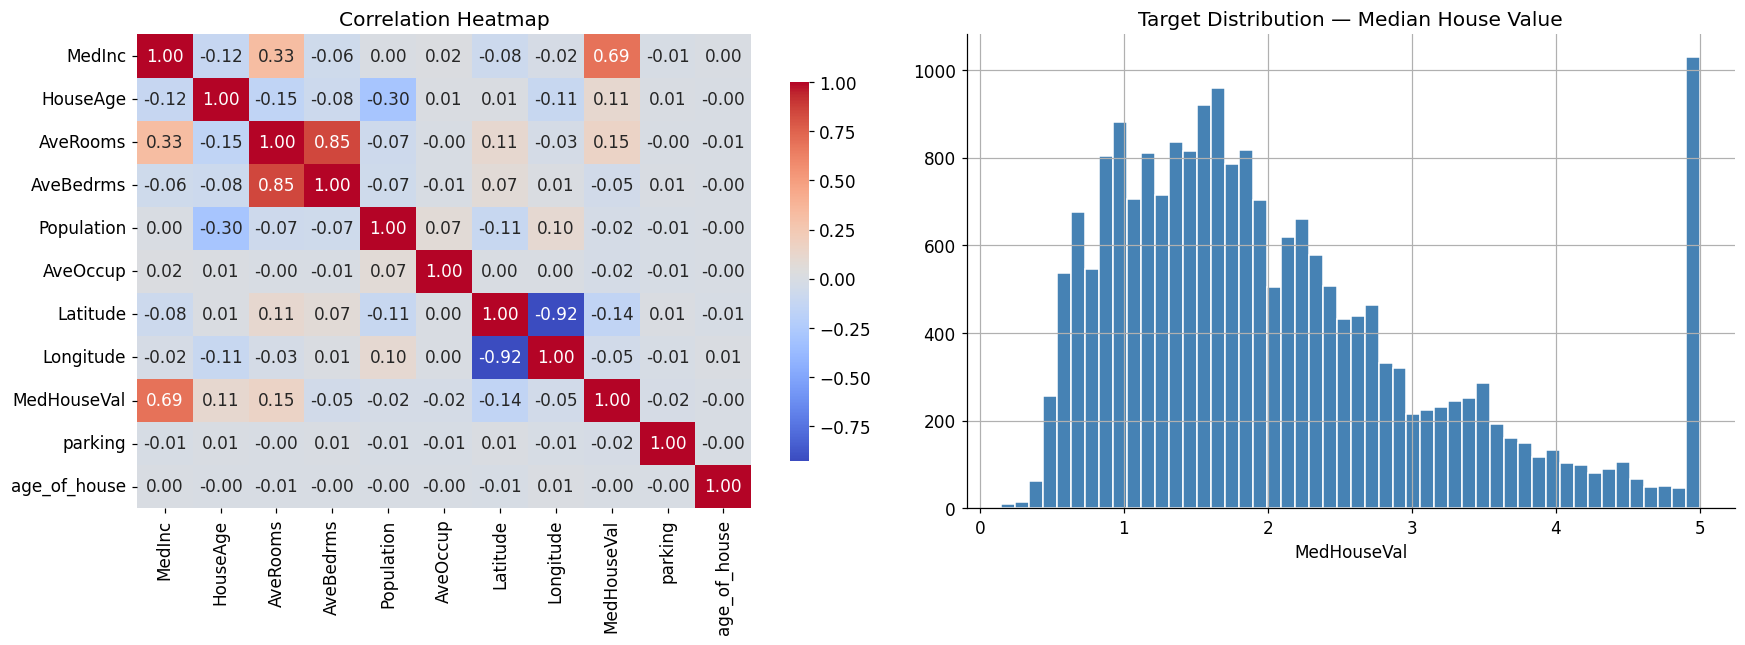

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

num_cols = df2.select_dtypes(include=np.number).columns
corr = df2[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Correlation Heatmap')

df2['MedHouseVal'].hist(bins=50, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Target Distribution — Median House Value')
axes[1].set_xlabel('MedHouseVal')

plt.tight_layout()
plt.show()

In [11]:
df2.fillna(df2.median(numeric_only=True), inplace=True)
df2_encoded = pd.get_dummies(df2, columns=['location', 'furnishing'], drop_first=True)
print('Columns after encoding:', df2_encoded.columns.tolist())

Columns after encoding: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal', 'parking', 'age_of_house', 'location_Suburban', 'location_Urban', 'furnishing_Semi-Furnished', 'furnishing_Unfurnished']


In [12]:
df2_encoded['rooms_per_household'] = df2_encoded['AveRooms'] / (df2_encoded['HouseAge'] + 1)
df2_encoded['income_age_ratio']    = df2_encoded['MedInc'] / (df2_encoded['age_of_house'] + 1)
df2_encoded['log_income']          = np.log1p(df2_encoded['MedInc'])

num_features = df2_encoded.drop('MedHouseVal', axis=1).select_dtypes(include=np.number)
vif_data = pd.DataFrame()
vif_data['Feature'] = num_features.columns
vif_data['VIF'] = [variance_inflation_factor(num_features.values, i) for i in range(num_features.shape[1])]
print(vif_data.sort_values('VIF', ascending=False).to_string(index=False))

                  Feature        VIF
                Longitude 867.011906
                 Latitude 588.176377
               log_income 268.168791
                   MedInc  71.758749
                 AveRooms  51.605244
                AveBedrms  45.101250
                 HouseAge  10.967464
             age_of_house   6.901533
      rooms_per_household   4.076384
           location_Urban   3.506658
               Population   2.961822
         income_age_ratio   2.766452
        location_Suburban   2.500198
                  parking   2.494826
furnishing_Semi-Furnished   1.998551
   furnishing_Unfurnished   1.993655
                 AveOccup   1.095873


In [13]:
X2 = df2_encoded.drop('MedHouseVal', axis=1).select_dtypes(include=np.number)
y2 = df2_encoded['MedHouseVal']

X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y2, test_size=0.2, random_state=42)

slr = LinearRegression().fit(X2_tr[['MedInc']], y2_tr)
y_slr = slr.predict(X2_te[['MedInc']])

scaler2 = StandardScaler()
X2_tr_sc = scaler2.fit_transform(X2_tr)
X2_te_sc = scaler2.transform(X2_te)
mlr = LinearRegression().fit(X2_tr_sc, y2_tr)
y_mlr = mlr.predict(X2_te_sc)

r_slr = print_metrics(y2_te, y_slr, 'Simple LR (MedInc only)')
r_mlr = print_metrics(y2_te, y_mlr, 'Multiple LR (all features)')


Simple LR (MedInc only)
  MAE  = 0.6299
  MSE  = 0.7091
  RMSE = 0.8421
  R2   = 0.4589

Multiple LR (all features)
  MAE  = 0.5347
  MSE  = 0.5554
  RMSE = 0.7452
  R2   = 0.5762


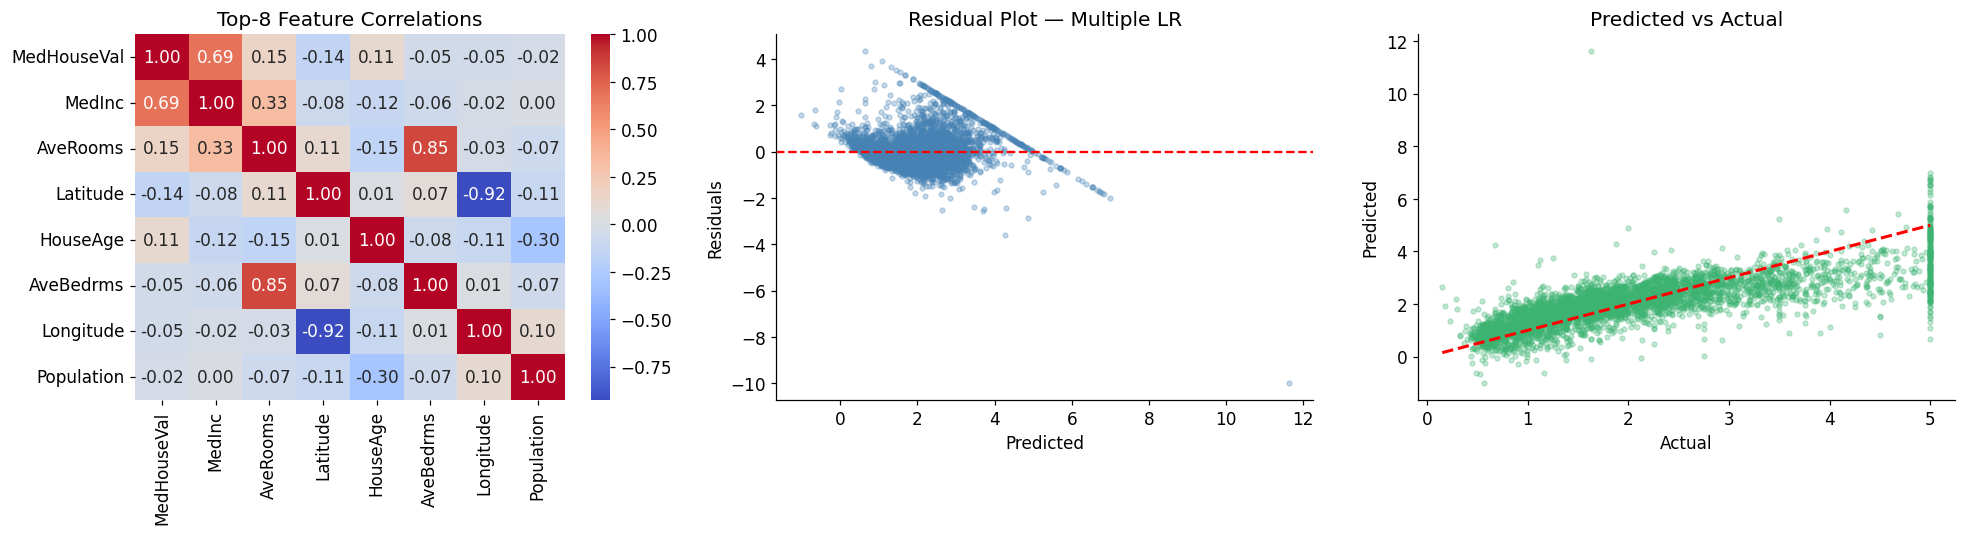

1. Top features influencing price: ['MedInc', 'AveRooms', 'Latitude']
2. Features causing multicollinearity (VIF>10): ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Latitude', 'Longitude', 'log_income']
3. R2 improved from 0.4589 to 0.5762


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

top_feats = corr['MedHouseVal'].abs().nlargest(8).index
sns.heatmap(df2[list(top_feats)].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0])
axes[0].set_title('Top-8 Feature Correlations')

res_mlr = y2_te - y_mlr
axes[1].scatter(y_mlr, res_mlr, alpha=0.3, color='steelblue', s=10)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residual Plot — Multiple LR')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residuals')

axes[2].scatter(y2_te, y_mlr, alpha=0.3, s=10, color='mediumseagreen')
mn, mx = y2_te.min(), y2_te.max()
axes[2].plot([mn, mx], [mn, mx], 'r--', lw=2)
axes[2].set_title('Predicted vs Actual')
axes[2].set_xlabel('Actual')
axes[2].set_ylabel('Predicted')

plt.tight_layout()
plt.show()

top3 = corr['MedHouseVal'].abs().nlargest(4).drop('MedHouseVal')
high_vif = vif_data[vif_data['VIF'] > 10]['Feature'].tolist()
print(f'1. Top features influencing price: {list(top3.index)}')
print(f'2. Features causing multicollinearity (VIF>10): {high_vif}')
print(f'3. R2 improved from {r_slr["R2"]:.4f} to {r_mlr["R2"]:.4f}')

---
## 📌 Assignment 3 — Detect and Fix Multicollinearity
> Understand multicollinearity problems using the **Advertising Dataset**.

In [17]:
try:
    df3 = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv', index_col=0)
    df3.columns = [c.strip().capitalize() for c in df3.columns]
    df3.rename(columns={'Tv': 'TV'}, inplace=True)
except Exception:
    np.random.seed(42)
    n3   = 200
    tv   = np.random.uniform(0, 300, n3)
    radio= np.random.uniform(0, 50, n3)
    news = 0.7 * radio + np.random.normal(0, 5, n3)
    sales= 0.05*tv + 0.2*radio + 0.01*news + np.random.normal(0, 2, n3)
    df3  = pd.DataFrame({'TV': tv, 'Radio': radio, 'Newspaper': news, 'Sales': sales})

print('Columns:', df3.columns.tolist())
print('Shape:', df3.shape)
df3.head()

Columns: ['TV', 'Radio', 'Newspaper', 'Sales']
Shape: (200, 4)


,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [18]:
X3 = df3[['TV', 'Radio', 'Newspaper']]
y3 = df3['Sales']
X3_tr, X3_te, y3_tr, y3_te = train_test_split(X3, y3, test_size=0.2, random_state=42)

base_model = LinearRegression().fit(X3_tr, y3_tr)
r_base = print_metrics(y3_te, base_model.predict(X3_te), 'Baseline (TV+Radio+Newspaper)')

print(pd.DataFrame({'Feature': X3.columns, 'Coefficient': base_model.coef_}).to_string(index=False))


Baseline (TV+Radio+Newspaper)
  MAE  = 1.4608
  MSE  = 3.1741
  RMSE = 1.7816
  R2   = 0.8994
  Feature  Coefficient
       TV     0.044730
    Radio     0.189195
Newspaper     0.002761


  Feature      VIF
       TV 2.486772
    Radio 3.285462
Newspaper 3.055245


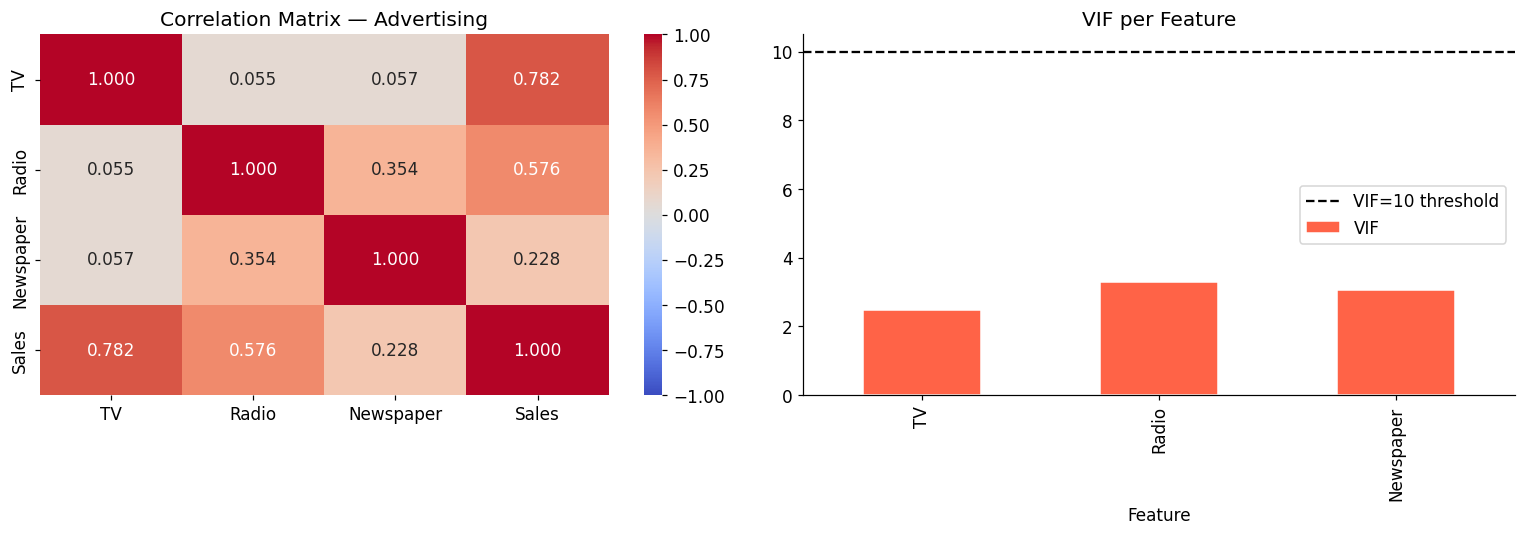

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(df3.corr(), annot=True, fmt='.3f', cmap='coolwarm', ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Correlation Matrix — Advertising')

vif3 = pd.DataFrame()
vif3['Feature'] = X3.columns
vif3['VIF'] = [variance_inflation_factor(X3.values, i) for i in range(X3.shape[1])]
print(vif3.to_string(index=False))

vif3.plot(kind='bar', x='Feature', y='VIF', ax=axes[1], color='tomato', edgecolor='white')
axes[1].axhline(10, color='black', linestyle='--', label='VIF=10 threshold')
axes[1].set_title('VIF per Feature')
axes[1].legend()

plt.tight_layout()
plt.show()

In [20]:
X3_clean = df3[['TV', 'Radio']]
X3c_tr, X3c_te, _, _ = train_test_split(X3_clean, y3, test_size=0.2, random_state=42)

clean_model = LinearRegression().fit(X3c_tr, y3_tr)
r_clean = print_metrics(y3_te, clean_model.predict(X3c_te), 'Fixed (TV+Radio only)')

vif3c = pd.DataFrame()
vif3c['Feature'] = X3_clean.columns
vif3c['VIF'] = [variance_inflation_factor(X3_clean.values, i) for i in range(X3_clean.shape[1])]
print('VIF after removal:\n', vif3c.to_string(index=False))

print(pd.DataFrame([r_base, r_clean]).set_index('label').round(4))


Fixed (TV+Radio only)
  MAE  = 1.4443
  MSE  = 3.1379
  RMSE = 1.7714
  R2   = 0.9006
VIF after removal:
 Feature      VIF
     TV 2.238085
  Radio 2.238085
                                  MAE     MSE    RMSE      R2
label                                                        
Baseline (TV+Radio+Newspaper)  1.4608  3.1741  1.7816  0.8994
Fixed (TV+Radio only)          1.4443  3.1379  1.7714  0.9006


---
## 📌 Assignment 4 — Residual Analysis & Model Diagnostics
> Check whether **Linear Regression assumptions** are satisfied.

In [21]:
X4_tr, X4_te, y4_tr, y4_te = train_test_split(X1_norm, y1, test_size=0.2, random_state=42)

model4  = LinearRegression().fit(X4_tr, y4_tr)
y4_pred = model4.predict(X4_te)
residuals = y4_te - y4_pred

print_metrics(y4_te, y4_pred, 'LR — California Housing')


LR — California Housing
  MAE  = 0.4594
  MSE  = 0.3688
  RMSE = 0.6073
  R2   = 0.6013


{'label': 'LR — California Housing',
 'MAE': 0.45941899965752864,
 'MSE': 0.3687634762591091,
 'RMSE': 0.6072589861493275,
 'R2': 0.6012592989543193}

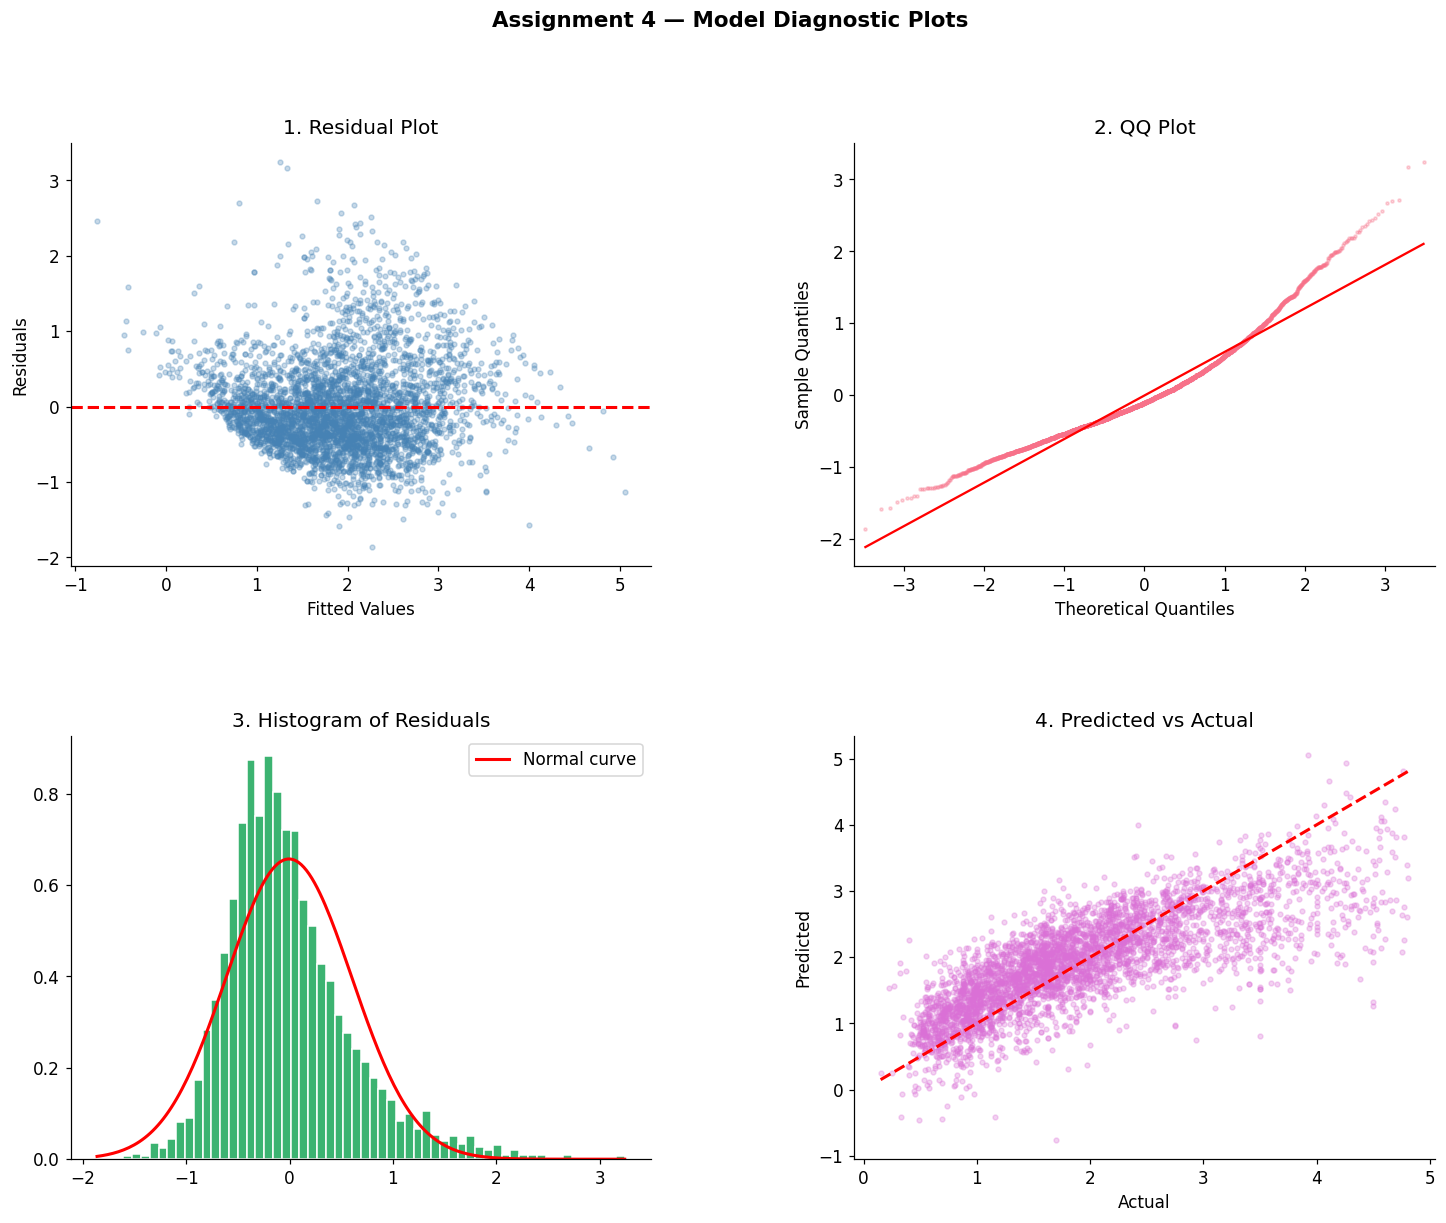

In [22]:
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y4_pred, residuals, alpha=0.3, s=10, color='steelblue')
ax1.axhline(0, color='red', lw=2, ls='--')
ax1.set_xlabel('Fitted Values')
ax1.set_ylabel('Residuals')
ax1.set_title('1. Residual Plot')

ax2 = fig.add_subplot(gs[0, 1])
sm.qqplot(residuals, line='s', ax=ax2, alpha=0.3, markersize=2)
ax2.set_title('2. QQ Plot')

ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(residuals, bins=60, color='mediumseagreen', edgecolor='white', density=True)
xr = np.linspace(residuals.min(), residuals.max(), 200)
ax3.plot(xr, stats.norm.pdf(xr, residuals.mean(), residuals.std()), 'r-', lw=2, label='Normal curve')
ax3.set_title('3. Histogram of Residuals')
ax3.legend()

ax4 = fig.add_subplot(gs[1, 1])
ax4.scatter(y4_te, y4_pred, alpha=0.3, s=10, color='orchid')
mn4, mx4 = y4_te.min(), y4_te.max()
ax4.plot([mn4, mx4], [mn4, mx4], 'r--', lw=2)
ax4.set_title('4. Predicted vs Actual')
ax4.set_xlabel('Actual')
ax4.set_ylabel('Predicted')

plt.suptitle('Assignment 4 — Model Diagnostic Plots', fontsize=14, fontweight='bold')
plt.show()

In [24]:
stat_sw, p_sw = stats.shapiro(residuals[:5000])
lm, p_bp, fval, p_f = sm.stats.diagnostic.het_breuschpagan(residuals, sm.add_constant(y4_pred))

print(f'1. Normality — Shapiro-Wilk p={p_sw:.4f}  → {"Roughly normal" if p_sw > 0.05 else "Not perfectly normal"}')
print(f'2. Heteroscedasticity — Breusch-Pagan p={p_bp:.4f} → {"Detected" if p_bp < 0.05 else "Not detected"}')
print('3. Fixes: log/sqrt transform, WLS for heteroscedasticity, polynomial features for non-linearity')

1. Normality — Shapiro-Wilk p=0.0000  → Not perfectly normal
2. Heteroscedasticity — Breusch-Pagan p=0.0000 → Detected
3. Fixes: log/sqrt transform, WLS for heteroscedasticity, polynomial features for non-linearity


---
## 📌 Assignment 5 — Compare Linear Regression With Regularization
> Understand when LR **fails** and how Ridge / Lasso **help**.

In [25]:
diab = load_diabetes(as_frame=True)
X5, y5 = diab.data, diab.target

poly = PolynomialFeatures(degree=2, include_bias=False)
X5_poly = pd.DataFrame(poly.fit_transform(X5), columns=poly.get_feature_names_out(X5.columns))
print(f'Original features: {X5.shape[1]}  →  After poly: {X5_poly.shape[1]}')

X5_tr, X5_te, y5_tr, y5_te = train_test_split(X5_poly, y5, test_size=0.2, random_state=42)
sc5 = StandardScaler()
X5_tr_sc = sc5.fit_transform(X5_tr)
X5_te_sc = sc5.transform(X5_te)

Original features: 10  →  After poly: 65


In [26]:
lr5  = LinearRegression().fit(X5_tr_sc, y5_tr)
rid5 = Ridge(alpha=1.0).fit(X5_tr_sc, y5_tr)
las5 = Lasso(alpha=0.5, max_iter=5000).fit(X5_tr_sc, y5_tr)

r_lr5  = print_metrics(y5_te, lr5.predict(X5_te_sc),  'Linear Regression')
r_rid5 = print_metrics(y5_te, rid5.predict(X5_te_sc), 'Ridge Regression (alpha=1.0)')
r_las5 = print_metrics(y5_te, las5.predict(X5_te_sc), 'Lasso Regression (alpha=0.5)')

cmp5 = pd.DataFrame([r_lr5, r_rid5, r_las5]).set_index('label')
print(cmp5.round(4))


Linear Regression
  MAE  = 43.5710
  MSE  = 3091.1464
  RMSE = 55.5981
  R2   = 0.4166

Ridge Regression (alpha=1.0)
  MAE  = 41.7144
  MSE  = 2883.3630
  RMSE = 53.6970
  R2   = 0.4558

Lasso Regression (alpha=0.5)
  MAE  = 39.5382
  MSE  = 2581.6107
  RMSE = 50.8096
  R2   = 0.5127
                                  MAE        MSE     RMSE      R2
label                                                            
Linear Regression             43.5710  3091.1464  55.5981  0.4166
Ridge Regression (alpha=1.0)  41.7144  2883.3630  53.6970  0.4558
Lasso Regression (alpha=0.5)  39.5382  2581.6107  50.8096  0.5127


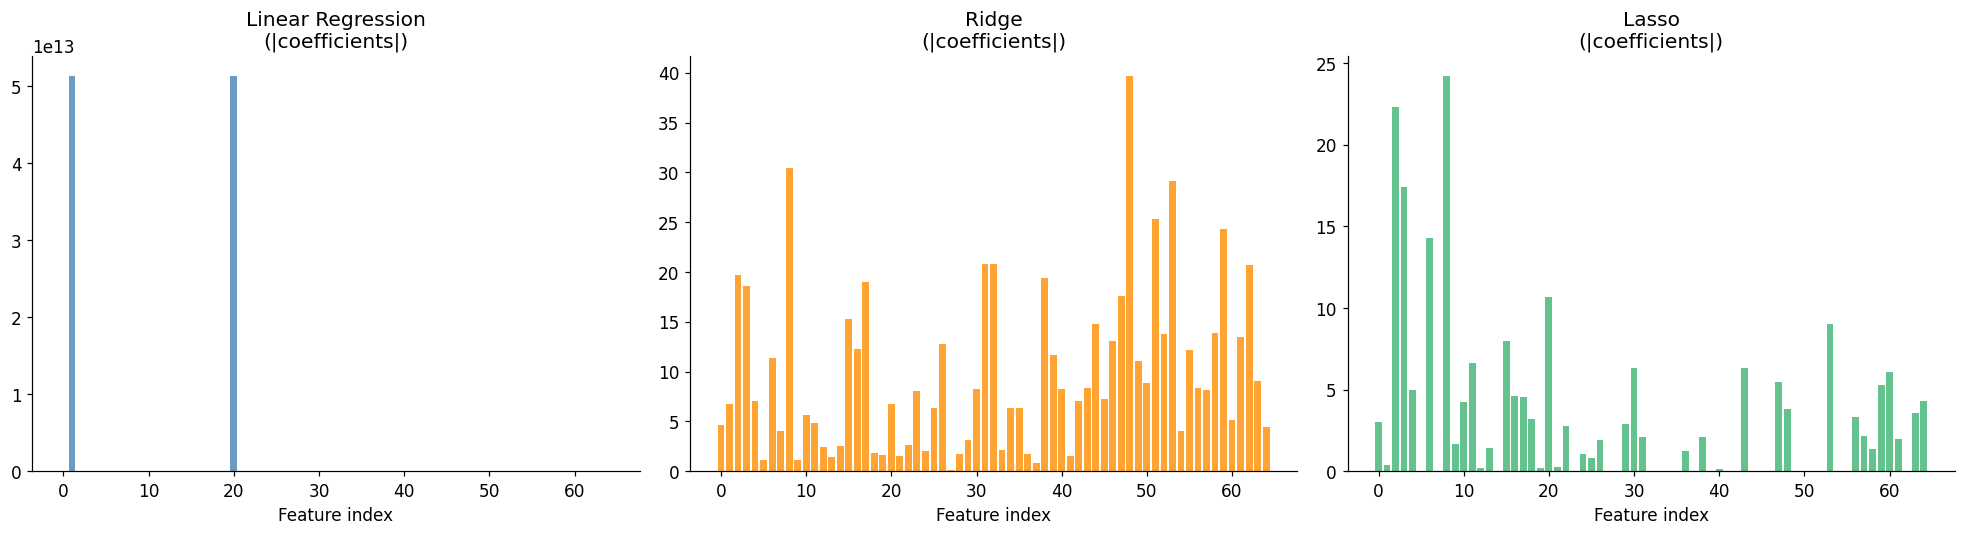

1. Best model: Lasso Regression (alpha=0.5) (R2=0.5127)
2. Ridge reduces overfitting by penalizing large weights (L2 norm).
3. Lasso zeroed 24/65 features — automatic feature selection.


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, model, name, color in zip(axes,
        [lr5, rid5, las5],
        ['Linear Regression', 'Ridge', 'Lasso'],
        ['steelblue', 'darkorange', 'mediumseagreen']):
    ax.bar(range(len(model.coef_)), np.abs(model.coef_), color=color, alpha=0.8)
    ax.set_title(f'{name}\n(|coefficients|)')
    ax.set_xlabel('Feature index')

plt.tight_layout()
plt.show()

n_zero = (las5.coef_ == 0).sum()
print(f'1. Best model: {cmp5["R2"].idxmax()} (R2={cmp5["R2"].max():.4f})')
print('2. Ridge reduces overfitting by penalizing large weights (L2 norm).')
print(f'3. Lasso zeroed {n_zero}/{len(las5.coef_)} features — automatic feature selection.')

---
## 📌 Assignment 6 — Build a Complete ML Pipeline
> Create a **production-style ML pipeline** with saving/loading.

In [28]:
np.random.seed(0)
n6     = 1338
age    = np.random.randint(18, 65, n6)
sex    = np.random.choice(['male', 'female'], n6)
bmi    = np.random.normal(30, 6, n6).clip(15, 55).round(2)
kids   = np.random.choice([0,1,2,3,4,5], n6, p=[0.4,0.25,0.2,0.1,0.03,0.02])
smoker = np.random.choice(['yes', 'no'], n6, p=[0.2, 0.8])
region = np.random.choice(['NE', 'SE', 'SW', 'NW'], n6)
charges = (1000 + 250*age + 400*bmi + 5000*(smoker=='yes') + 300*kids + np.random.normal(0, 2000, n6)).clip(1000)
df6 = pd.DataFrame(dict(age=age, sex=sex, bmi=bmi, children=kids, smoker=smoker, region=region, charges=charges))
df6.head()

,age,sex,bmi,children,smoker,region,charges
0,62,male,26.75,2,no,SE,27807.818041
1,18,female,28.80,0,no,SW,14096.457353
2,21,female,26.10,0,no,SE,17087.751865
3,21,female,22.55,4,no,SE,17349.949838
4,57,male,41.96,2,yes,NW,35075.729388


In [29]:
X6 = df6.drop('charges', axis=1)
y6 = df6['charges']
X6_tr, X6_te, y6_tr, y6_te = train_test_split(X6, y6, test_size=0.2, random_state=42)

num_cols6 = ['age', 'bmi', 'children']
cat_cols6 = ['sex', 'smoker', 'region']

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols6),
    ('cat', cat_pipe, cat_cols6)
])
full_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model',      Ridge())
])

param_grid = {'model__alpha': [0.01, 0.1, 1, 10, 100, 1000]}
grid_search = GridSearchCV(full_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X6_tr, y6_tr)

best_pipe = grid_search.best_estimator_
print(f'Best alpha: {grid_search.best_params_}')
print(f'Best CV R2: {grid_search.best_score_:.4f}')

Best alpha: {'model__alpha': 1}
Best CV R2: 0.8376



Production Ridge Pipeline
  MAE  = 1616.8814
  MSE  = 4245153.8126
  RMSE = 2060.3771
  R2   = 0.8273
Model saved and verified: insurance_model.pkl


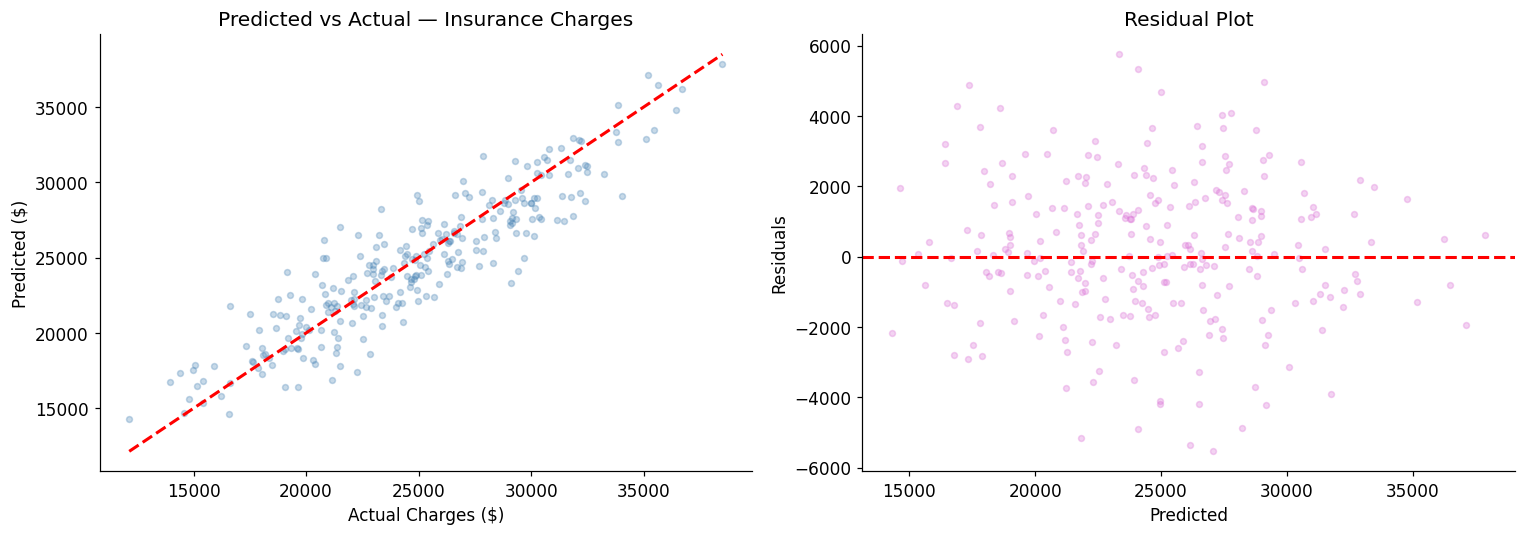

In [30]:
y6_pred = best_pipe.predict(X6_te)
r6 = print_metrics(y6_te, y6_pred, 'Production Ridge Pipeline')

joblib.dump(best_pipe, 'insurance_model.pkl')
loaded_model = joblib.load('insurance_model.pkl')
assert np.allclose(loaded_model.predict(X6_te), y6_pred)
print('Model saved and verified: insurance_model.pkl')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y6_te, y6_pred, alpha=0.3, s=15, color='steelblue')
mn6, mx6 = y6_te.min(), y6_te.max()
axes[0].plot([mn6, mx6], [mn6, mx6], 'r--', lw=2)
axes[0].set_title('Predicted vs Actual — Insurance Charges')
axes[0].set_xlabel('Actual Charges ($)')
axes[0].set_ylabel('Predicted ($)')

res6 = y6_te - y6_pred
axes[1].scatter(y6_pred, res6, alpha=0.3, s=15, color='orchid')
axes[1].axhline(0, color='red', ls='--', lw=2)
axes[1].set_title('Residual Plot')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

---
## 📌 Bonus — Salary Prediction System
> Predict **salary** based on experience, education, skills, and location.

In [31]:
np.random.seed(7)
n7 = 1500
experience   = np.random.randint(0, 30, n7)
education    = np.random.choice(['HighSchool','Bachelor','Master','PhD'], n7, p=[0.15,0.50,0.25,0.10])
skills_score = np.random.uniform(1, 10, n7).round(1)
location7    = np.random.choice(['Tier1','Tier2','Tier3'], n7, p=[0.35,0.40,0.25])
job_type     = np.random.choice(['Engineer','Manager','Analyst','Designer'], n7)
edu_num      = {'HighSchool':0,'Bachelor':1,'Master':2,'PhD':3}
loc_mul      = {'Tier1':1.4,'Tier2':1.0,'Tier3':0.7}

salary = (
    25000 + 3000*experience +
    15000*np.array([edu_num[e] for e in education]) +
    2500*skills_score +
    np.array([loc_mul[l]*10000 for l in location7]) +
    np.random.normal(0, 8000, n7)
).clip(20000)

df7 = pd.DataFrame(dict(experience=experience, education=education,
                         skills_score=skills_score, location=location7,
                         job_type=job_type, salary=salary.round(0)))
df7.head()

,experience,education,skills_score,location,job_type,salary
0,15,Bachelor,5.5,Tier1,Manager,113646.0
1,4,HighSchool,2.8,Tier1,Manager,36605.0
2,25,Bachelor,1.9,Tier2,Engineer,129647.0
3,22,Bachelor,3.3,Tier1,Engineer,113045.0
4,3,PhD,1.3,Tier2,Engineer,99260.0


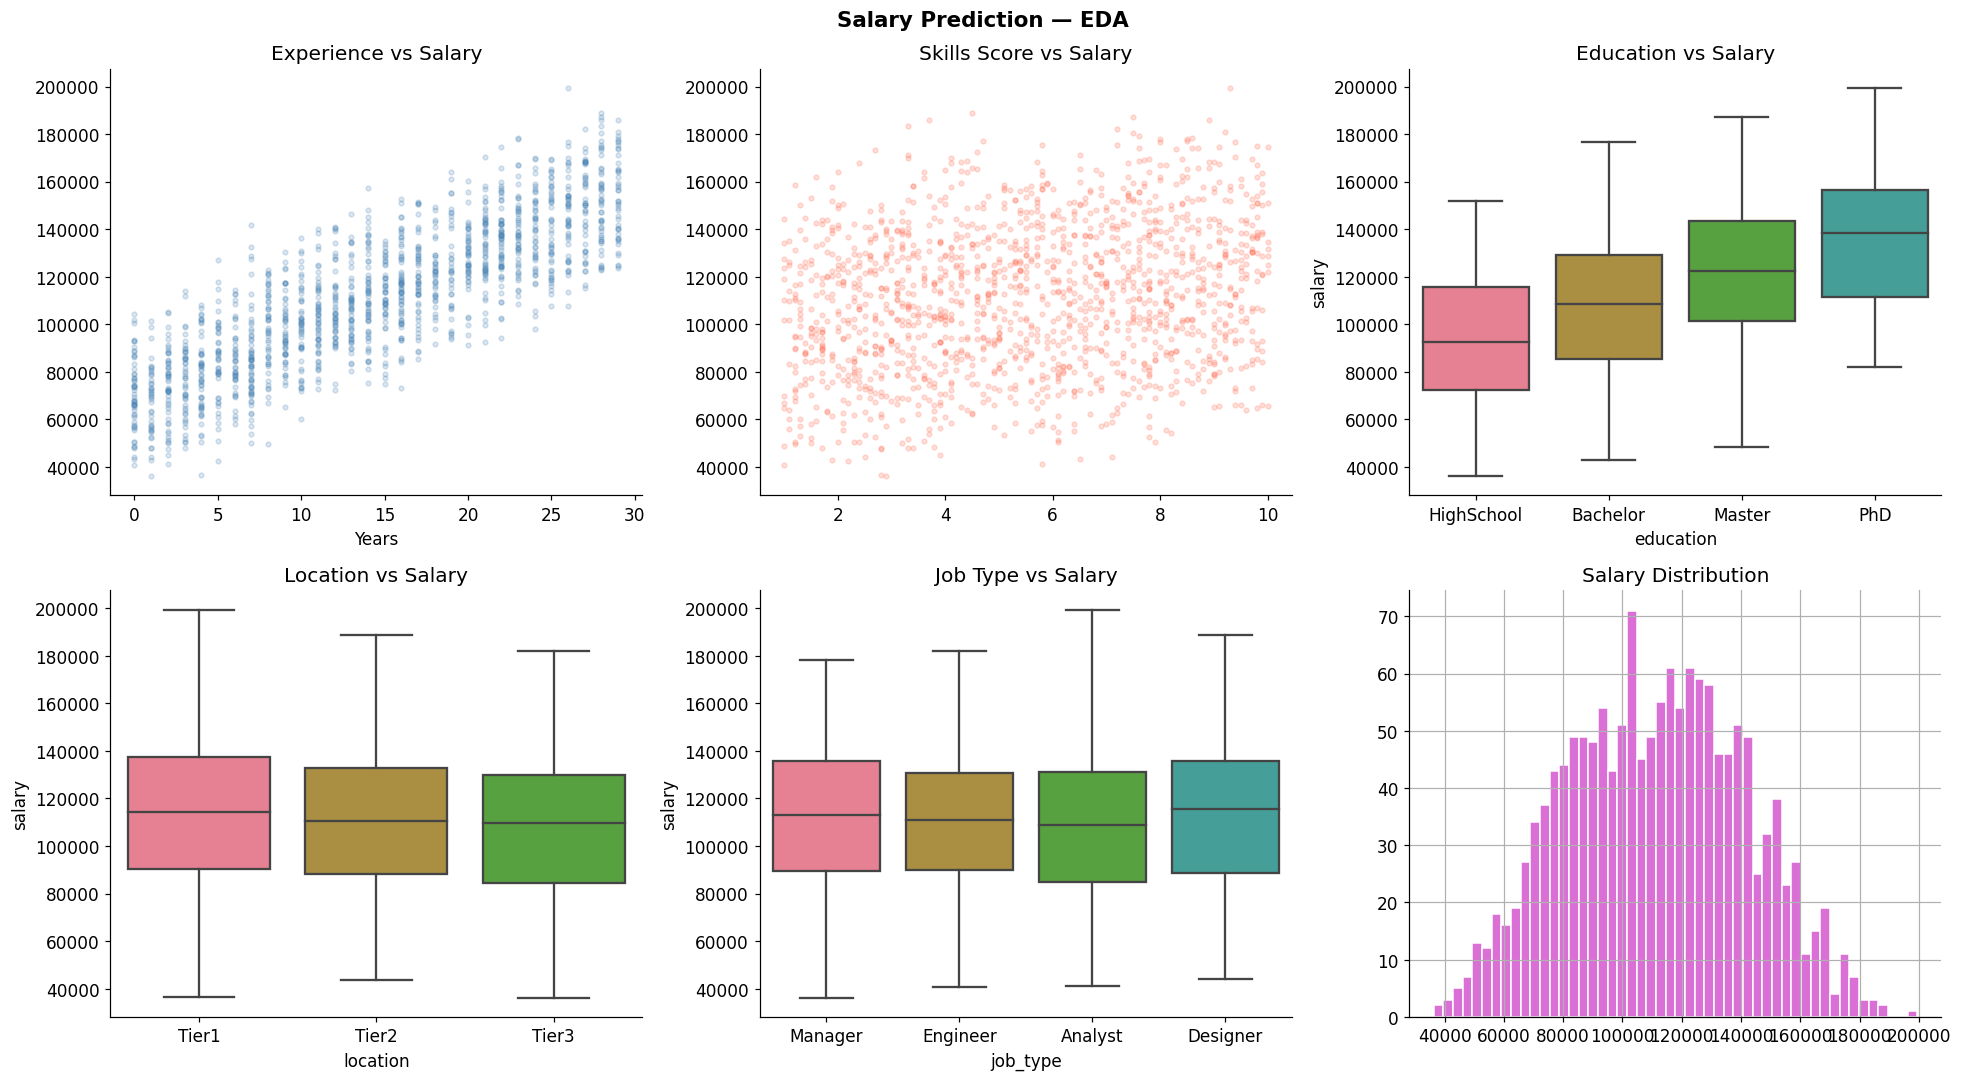

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0,0].scatter(df7['experience'], df7['salary'], alpha=0.2, s=10, color='steelblue')
axes[0,0].set_title('Experience vs Salary')
axes[0,0].set_xlabel('Years')

axes[0,1].scatter(df7['skills_score'], df7['salary'], alpha=0.2, s=10, color='tomato')
axes[0,1].set_title('Skills Score vs Salary')

sns.boxplot(data=df7, x='education', y='salary', order=['HighSchool','Bachelor','Master','PhD'], ax=axes[0,2])
axes[0,2].set_title('Education vs Salary')

sns.boxplot(data=df7, x='location', y='salary', ax=axes[1,0])
axes[1,0].set_title('Location vs Salary')

sns.boxplot(data=df7, x='job_type', y='salary', ax=axes[1,1])
axes[1,1].set_title('Job Type vs Salary')

df7['salary'].hist(bins=50, ax=axes[1,2], color='orchid', edgecolor='white')
axes[1,2].set_title('Salary Distribution')

plt.suptitle('Salary Prediction — EDA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [33]:
df7_enc = pd.get_dummies(df7, columns=['education','location','job_type'], drop_first=False)
df7_enc['exp_x_skills'] = df7_enc['experience'] * df7_enc['skills_score']
df7_enc['log_exp']      = np.log1p(df7_enc['experience'])

X7 = df7_enc.drop('salary', axis=1)
y7 = df7_enc['salary']

num7 = X7[['experience','skills_score','exp_x_skills','log_exp']]
vif7 = pd.DataFrame({'Feature': num7.columns,
                     'VIF': [variance_inflation_factor(num7.values, i) for i in range(num7.shape[1])]})
print(vif7.to_string(index=False))

     Feature       VIF
  experience 42.427057
skills_score 10.713353
exp_x_skills 13.863248
     log_exp 39.096757


In [34]:
X7_tr, X7_te, y7_tr, y7_te = train_test_split(X7, y7, test_size=0.2, random_state=42)
sc7 = StandardScaler()
X7_tr_sc = sc7.fit_transform(X7_tr)
X7_te_sc = sc7.transform(X7_te)

m_lr7  = LinearRegression().fit(X7_tr_sc, y7_tr)
m_rid7 = Ridge(alpha=10).fit(X7_tr_sc, y7_tr)
m_las7 = Lasso(alpha=50, max_iter=10000).fit(X7_tr_sc, y7_tr)

r_lr7  = print_metrics(y7_te, m_lr7.predict(X7_te_sc),  'Linear Regression')
r_rid7 = print_metrics(y7_te, m_rid7.predict(X7_te_sc), 'Ridge (alpha=10)')
r_las7 = print_metrics(y7_te, m_las7.predict(X7_te_sc), 'Lasso (alpha=50)')

print(pd.DataFrame([r_lr7, r_rid7, r_las7]).set_index('label').round(2))


Linear Regression
  MAE  = 6313.2399
  MSE  = 62948271.7458
  RMSE = 7933.9947
  R2   = 0.9230

Ridge (alpha=10)
  MAE  = 6296.0585
  MSE  = 62956689.1159
  RMSE = 7934.5251
  R2   = 0.9230

Lasso (alpha=50)
  MAE  = 6311.2503
  MSE  = 62903854.6694
  RMSE = 7931.1950
  R2   = 0.9230
                       MAE          MSE     RMSE    R2
label                                                 
Linear Regression  6313.24  62948271.75  7933.99  0.92
Ridge (alpha=10)   6296.06  62956689.12  7934.53  0.92
Lasso (alpha=50)   6311.25  62903854.67  7931.20  0.92


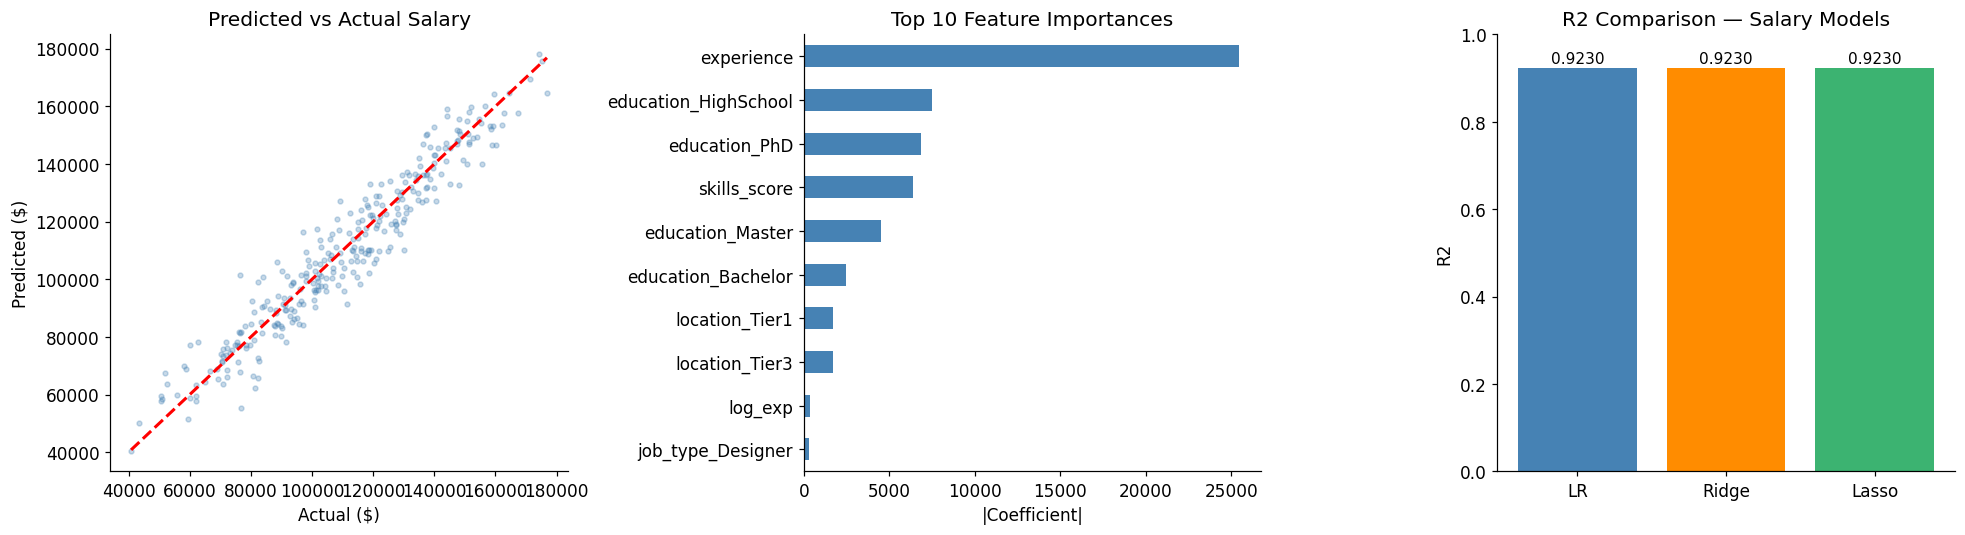

In [35]:
y7_best = m_lr7.predict(X7_te_sc)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y7_te, y7_best, alpha=0.3, s=10, color='steelblue')
mn7, mx7 = y7_te.min(), y7_te.max()
axes[0].plot([mn7, mx7], [mn7, mx7], 'r--', lw=2)
axes[0].set_title('Predicted vs Actual Salary')
axes[0].set_xlabel('Actual ($)')
axes[0].set_ylabel('Predicted ($)')

coef7 = pd.Series(np.abs(m_lr7.coef_), index=X7.columns)
coef7.nlargest(10).sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 10 Feature Importances')
axes[1].set_xlabel('|Coefficient|')

r2_vals = {'LR': r_lr7['R2'], 'Ridge': r_rid7['R2'], 'Lasso': r_las7['R2']}
axes[2].bar(r2_vals.keys(), r2_vals.values(), color=['steelblue','darkorange','mediumseagreen'])
axes[2].set_ylim(0, 1)
axes[2].set_title('R2 Comparison — Salary Models')
axes[2].set_ylabel('R2')
for i, (k, v) in enumerate(r2_vals.items()):
    axes[2].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

---
## 📋 Final Summary

In [36]:
all_results = [
    {'Assignment': 'A1', **r1a},
    {'Assignment': 'A1', **r1b},
    {'Assignment': 'A1', **r1c},
    {'Assignment': 'A2', **r_slr},
    {'Assignment': 'A2', **r_mlr},
    {'Assignment': 'A3', **r_base},
    {'Assignment': 'A3', **r_clean},
    {'Assignment': 'A5', **r_lr5},
    {'Assignment': 'A5', **r_rid5},
    {'Assignment': 'A5', **r_las5},
    {'Assignment': 'A6', **r6},
    {'Assignment': 'Bonus', **r_lr7},
    {'Assignment': 'Bonus', **r_rid7},
    {'Assignment': 'Bonus', **r_las7},
]

summary_df = pd.DataFrame(all_results)[['Assignment','label','MAE','MSE','RMSE','R2']].round(4)
print(summary_df.to_string(index=False))

Assignment                         label       MAE          MSE      RMSE     R2
        A1         Scratch GD  (lr=0.05)    0.4645 3.930000e-01    0.6269 0.6162
        A1         Scratch SGD (lr=0.01)    0.4765 5.093000e-01    0.7137 0.5027
        A1      sklearn LinearRegression    0.4642 3.883000e-01    0.6231 0.6209
        A2       Simple LR (MedInc only)    0.6299 7.091000e-01    0.8421 0.4589
        A2    Multiple LR (all features)    0.5347 5.554000e-01    0.7452 0.5762
        A3 Baseline (TV+Radio+Newspaper)    1.4608 3.174100e+00    1.7816 0.8994
        A3         Fixed (TV+Radio only)    1.4443 3.137900e+00    1.7714 0.9006
        A5             Linear Regression   43.5710 3.091146e+03   55.5981 0.4166
        A5  Ridge Regression (alpha=1.0)   41.7144 2.883363e+03   53.6970 0.4558
        A5  Lasso Regression (alpha=0.5)   39.5382 2.581611e+03   50.8096 0.5127
        A6     Production Ridge Pipeline 1616.8814 4.245154e+06 2060.3771 0.8273
     Bonus             Linea